<a href="https://colab.research.google.com/github/10kshaodow/Deep-Learning-Lab-2/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib as plt
import torch
import torch.nn.functional as f
from datasets import load_dataset
import os
import math
import random
from transformers import DataCollatorForSeq2Seq
from torch.utils.data import DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [19]:
import os
from datasets import load_dataset, load_from_disk

# https://huggingface.co/datasets/wmt/wmt14
ds = load_dataset("wmt/wmt14", "de-en")
train_ds = ds["train"]
test_ds = ds["test"]
val_ds = ds["validation"]

tokenizer_train_ds = train_ds.select(range(500000))

tokenizer = None
tokenizer_path = "/content/drive/MyDrive/CMPE-679-Labs/Lab2-Transformer/my_trained_tokenizer.json"

if not os.path.exists(tokenizer_path):
    print(f"Tokenizer file not found at {tokenizer_path}. Starting training...")

    tokenizer_core = Tokenizer(BPE(unk_token="[UNK]"))

    trainer = BpeTrainer(
        vocab_size=37000,
        special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
    )

    tokenizer_core.pre_tokenizer = Whitespace()

    def tokenizer_generator(ds):
        for row in ds:
            yield row["translation"]["en"]
            yield row["translation"]["de"]

    tokenizer_dir = os.path.dirname(tokenizer_path)
    os.makedirs(tokenizer_dir, exist_ok=True)

    tokenizer_core.train_from_iterator(tokenizer_generator(tokenizer_train_ds), trainer)
    tokenizer_core.save(tokenizer_path)

    print(f"Tokenizer trained and saved to {tokenizer_path}.")

    tokenizer = PreTrainedTokenizerFast(tokenizer_object=tokenizer_core)
    tokenizer.pad_token = "[PAD]"
    tokenizer.bos_token = "[BOS]"
    tokenizer.eos_token = "[EOS]"

else:
    print(f"Tokenizer file found at {tokenizer_path}. Loading existing tokenizer...")
    tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_path)
    tokenizer.pad_token = "[PAD]"
    tokenizer.bos_token = "[BOS]"
    tokenizer.eos_token = "[EOS]"
    print("Tokenizer loaded successfully.")


max_len = 64
batch_size = 128


def preprocess(batch):
    src = batch["translation"]["de"]
    tgt = batch["translation"]["en"]

    src_enc = tokenizer(
        src,
        max_length=max_len,
        truncation=True,
        padding=False
    )

    tgt_enc = tokenizer(
        tgt,
        max_length=max_len - 2,
        truncation=True,
        padding=False
    )

    labels = [tokenizer.bos_token_id] + tgt_enc["input_ids"] + [tokenizer.eos_token_id]

    model_inputs = {
        "input_ids": src_enc["input_ids"],
        "attention_mask": src_enc["attention_mask"],
        "labels": labels
    }

    return model_inputs


# Paths to save/load processed datasets
processed_base_path = "/content/drive/MyDrive/CMPE-679-Labs/Lab2-Transformer/processed_wmt14_de_en"
train_tokens_path = os.path.join(processed_base_path, "train_tokens")
test_tokens_path = os.path.join(processed_base_path, "test_tokens")
val_tokens_path = os.path.join(processed_base_path, "val_tokens")

# If already processed, load from disk
if (
    os.path.exists(train_tokens_path) and
    os.path.exists(test_tokens_path) and
    os.path.exists(val_tokens_path)
):
    print("Processed datasets found. Loading from disk...")
    train_tokens = load_from_disk(train_tokens_path)
    test_tokens = load_from_disk(test_tokens_path)
    val_tokens = load_from_disk(val_tokens_path)
    print("Processed datasets loaded successfully.")

else:
    print("Processed datasets not found. Running preprocessing...")

    train_tokens = train_ds.map(
        preprocess,
        remove_columns=train_ds.column_names,
        num_proc=4
    )

    test_tokens = test_ds.map(
        preprocess,
        remove_columns=test_ds.column_names,
        num_proc=4
    )

    val_tokens = val_ds.map(
        preprocess,
        remove_columns=val_ds.column_names,
        num_proc=4
    )

    os.makedirs(processed_base_path, exist_ok=True)

    train_tokens.save_to_disk(train_tokens_path)
    test_tokens.save_to_disk(test_tokens_path)
    val_tokens.save_to_disk(val_tokens_path)

    print("Processed datasets saved to disk.")

train_tokens = train_tokens.shuffle(seed=42).select(range(200000))
val_tokens = val_tokens.shuffle(seed=42).select(range(3000))
test_tokens = test_tokens.shuffle(seed=42).select(range(3003))

collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=tokenizer.pad_token_id
)

train_loader = DataLoader(
    train_tokens,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collator
)

test_loader = DataLoader(
    test_tokens,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collator
)

val_loader = DataLoader(
    val_tokens,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

Tokenizer file found at /content/drive/MyDrive/CMPE-679-Labs/Lab2-Transformer/my_trained_tokenizer.json. Loading existing tokenizer...
Tokenizer loaded successfully.
Processed datasets found. Loading from disk...
Processed datasets loaded successfully.


#Positional Encoding

In [5]:
import torch.nn as nn
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # Create a matrix of shape (max_len, d_model) filled with zeros
        pe = torch.zeros(max_len, d_model)

        # Create a vector of positions (0, 1, 2, ..., max_len-1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Calculate the division term for the sine and cosine functions
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension and register as a buffer (not a trainable parameter)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, d_model)

        Adds the positional encoding vectors to
        the token embeddings so the model knows
        the order of words in the sequence.
        """

        seq_len = x.size(1) # extracts the x_shape seq_len(size of sentence)
        return x + self.pe[:, :seq_len, :]

#Scaled attention

In [6]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask=None):
        """
        Q shape: (batch_size, num_heads, seq_len_q, d_k)
        K shape: (batch_size, num_heads, seq_len_k, d_k)
        V shape: (batch_size, num_heads, seq_len_v, d_v)
        mask shape: broadcastable to (batch_size, num_heads, seq_len_q, seq_len_k)
        """

        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        # scores shape: (batch_size, num_heads, seq_len_q, seq_len_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attention_weights = torch.softmax(scores, dim=-1)

        output = torch.matmul(attention_weights, V)
        # output shape: (batch_size, num_heads, seq_len_q, d_v)

        return output, attention_weights

#Multi-Head Attention

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final output projection
        self.W_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

    def split_heads(self, x):
        """
        x shape: (batch_size, seq_len, d_model)
        returns: (batch_size, num_heads, seq_len, d_k)
        """
        batch_size, seq_len, _ = x.size()

        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        x = x.transpose(1, 2)

        return x

    def combine_heads(self, x):
        """
        x shape: (batch_size, num_heads, seq_len, d_k)
        returns: (batch_size, seq_len, d_model)
        """
        batch_size, num_heads, seq_len, d_k = x.size()

        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, seq_len, num_heads * d_k)

        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V shape: (batch_size, seq_len, d_model)
        mask shape: broadcastable to (batch_size, num_heads, seq_len_q, seq_len_k)
        """

        # Linear projections
        Q = self.W_q(Q)
        K = self.W_k(K)
        V = self.W_v(V)

        # Split into heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Apply attention
        attention_output, attention_weights = self.attention(Q, K, V, mask)

        # Combine heads
        combined_output = self.combine_heads(attention_output)

        # Final linear layer
        output = self.W_o(combined_output)

        return output, attention_weights

#Feed Forward

In [8]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, d_model)
        """
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

#Encoder Layer

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        """
        x shape: (batch_size, src_seq_len, d_model)
        src_mask shape: broadcastable to attention scores
        """

        # Self-attention
        attn_output, attn_weights = self.self_attention(x, x, x, src_mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))

        return x, attn_weights

#Decoder Layer

In [10]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, tgt_mask=None, src_mask=None):
        """
        x shape: (batch_size, tgt_seq_len, d_model)
        enc_output shape: (batch_size, src_seq_len, d_model)
        tgt_mask: mask for decoder self-attention
        src_mask: mask for encoder-decoder attention
        """

        # Masked self-attention
        self_attn_output, self_attn_weights = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(self_attn_output))

        # Cross-attention: queries from decoder, keys/values from encoder
        cross_attn_output, cross_attn_weights = self.cross_attention(
            x, enc_output, enc_output, src_mask
        )
        x = self.norm2(x + self.dropout2(cross_attn_output))

        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))

        return x, self_attn_weights, cross_attn_weights

#Encoder

In [11]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=5000, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, src, src_mask=None):
        """
        src shape: (batch_size, src_seq_len)
        src_mask shape: (batch_size, 1, 1, src_seq_len)
        """
        x = self.embedding(src) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        attention_weights = []

        for layer in self.layers:
            x, attn = layer(x, src_mask)
            attention_weights.append(attn)

        return x, attention_weights

#Decoder

In [12]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=5000, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, tgt, enc_output, tgt_mask=None, src_mask=None):
        """
        tgt shape: (batch_size, tgt_seq_len)
        enc_output shape: (batch_size, src_seq_len, d_model)
        tgt_mask shape: (batch_size, 1, tgt_seq_len, tgt_seq_len)
        src_mask shape: (batch_size, 1, 1, src_seq_len)
        """
        x = self.embedding(tgt) * math.sqrt(self.embedding.embedding_dim)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        self_attention_weights = []
        cross_attention_weights = []

        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, enc_output, tgt_mask, src_mask)
            self_attention_weights.append(self_attn)
            cross_attention_weights.append(cross_attn)

        return x, self_attention_weights, cross_attention_weights

#Transformer Arch

In [13]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=512,
        num_heads=8,
        d_ff=2048,
        num_layers=6,
        max_len=5000,
        dropout=0.1,
        pad_token_id=0
    ):
        super().__init__()

        self.pad_token_id = pad_token_id

        self.encoder = Encoder(
            vocab_size=src_vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_layers,
            max_len=max_len,
            dropout=dropout
        )

        self.decoder = Decoder(
            vocab_size=tgt_vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_layers,
            max_len=max_len,
            dropout=dropout
        )

        self.output_projection = nn.Linear(d_model, tgt_vocab_size)

    def make_src_mask(self, src):
        """
        src shape: (batch_size, src_seq_len)
        returns: (batch_size, 1, 1, src_seq_len)
        """
        return (src != self.pad_token_id).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        """
        tgt shape: (batch_size, tgt_seq_len)

        padding mask:     (batch_size, 1, 1, tgt_seq_len)
        causal mask:      (1, 1, tgt_seq_len, tgt_seq_len)
        combined result:  (batch_size, 1, tgt_seq_len, tgt_seq_len)
        """
        batch_size, tgt_seq_len = tgt.size()

        pad_mask = (tgt != self.pad_token_id).unsqueeze(1).unsqueeze(2)

        causal_mask = torch.tril(
            torch.ones((tgt_seq_len, tgt_seq_len), device=tgt.device, dtype=torch.bool)
        ).unsqueeze(0).unsqueeze(1)

        return pad_mask & causal_mask

    def forward(self, src, tgt):
        """
        src shape: (batch_size, src_seq_len)
        tgt shape: (batch_size, tgt_seq_len)

        returns logits of shape: (batch_size, tgt_seq_len, tgt_vocab_size)
        """
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        enc_output, enc_attention = self.encoder(src, src_mask)

        dec_output, dec_self_attention, dec_cross_attention = self.decoder(
            tgt, enc_output, tgt_mask, src_mask
        )

        logits = self.output_projection(dec_output)

        return logits, enc_attention, dec_self_attention, dec_cross_attention

#Model

In [54]:
src_vocab_size = tokenizer.vocab_size
tgt_vocab_size = tokenizer.vocab_size

model = Transformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=512,
    num_heads=8,
    d_ff=2048,
    num_layers=6,
    max_len=128,
    dropout=0.1,
    pad_token_id=tokenizer.pad_token_id
).to(device)

#Train & Loss Funciton

In [15]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

In [16]:
import torch
from tqdm import tqdm

def _move_to_device(batch, device):
    if hasattr(batch, "items"):
        return {k: v.to(device) for k, v in batch.items()}
    if isinstance(batch, (tuple, list)) and len(batch) == 2:
        x, y = batch
        return x.to(device), y.to(device)
    raise TypeError(f"Unsupported batch type: {type(batch)}")


def train_epoch(model, dataloader, optimizer, device, criterion, pad_token_id):
    model.train()
    running_loss = 0.0
    total = 0

    pbar = tqdm(dataloader, desc="train", leave=False)
    for batch in pbar:
        optimizer.zero_grad(set_to_none=True)

        batch = _move_to_device(batch, device)

        src = batch["input_ids"]
        labels = batch["labels"]

        labels_for_input = labels.clone()
        labels_for_input[labels_for_input == pad_token_id] = pad_token_id

        tgt_input = labels_for_input[:, :-1]
        tgt_output = labels[:, 1:]

        logits, _, _, _ = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        batch_size = src.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size

    return running_loss / max(1, total)


def eval_epoch(model, dataloader, device, criterion, pad_token_id):
    model.eval()
    running_loss = 0.0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="eval", leave=False)
        for batch in pbar:
            batch = _move_to_device(batch, device)

            src = batch["input_ids"]
            labels = batch["labels"]

            labels_for_input = labels.clone()
            labels_for_input[labels_for_input == pad_token_id] = pad_token_id

            tgt_input = labels_for_input[:, :-1]
            tgt_output = labels[:, 1:]

            logits, _, _, _ = model(src, tgt_input)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )

            bs = src.size(0)
            running_loss += loss.item() * bs
            total += bs

    return running_loss / max(1, total)


def train(model, train_loader, val_loader, optimizer, scheduler, device, criterion, pad_token_id, epochs=5, patience=2):
    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, criterion, pad_token_id)
        val_loss = eval_epoch(model, val_loader, device, criterion, pad_token_id)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if scheduler is not None:
            try:
                scheduler.step(val_loss)
            except TypeError:
                scheduler.step()

        print(f"Epoch {epoch}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping triggered (patience={patience}). Best val loss: {best_val:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_val, train_losses, val_losses

In [17]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)

scheduler = None

In [29]:
model, best_val, train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    criterion=criterion,
    pad_token_id=tokenizer.pad_token_id,
    epochs=10,
    patience=2
)

Epoch 1/10 | train loss: 3.8389 | val loss: 4.2701


Epoch 2/10 | train loss: 3.6942 | val loss: 4.1952


Epoch 3/10 | train loss: 3.5666 | val loss: 4.1128


Epoch 4/10 | train loss: 3.4536 | val loss: 4.0734


Epoch 5/10 | train loss: 3.3497 | val loss: 4.0307


Epoch 6/10 | train loss: 3.2548 | val loss: 3.9937


Epoch 7/10 | train loss: 3.1669 | val loss: 3.9704


Epoch 8/10 | train loss: 3.0860 | val loss: 3.9496


Epoch 9/10 | train loss: 3.0104 | val loss: 3.9536


Epoch 10/10 | train loss: 2.9398 | val loss: 3.9424


In [30]:
model_save_path = "/content/drive/MyDrive/CMPE-679-Labs/Lab2-Transformer/transformer_model.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/CMPE-679-Labs/Lab2-Transformer/transformer_model.pth


#Plot

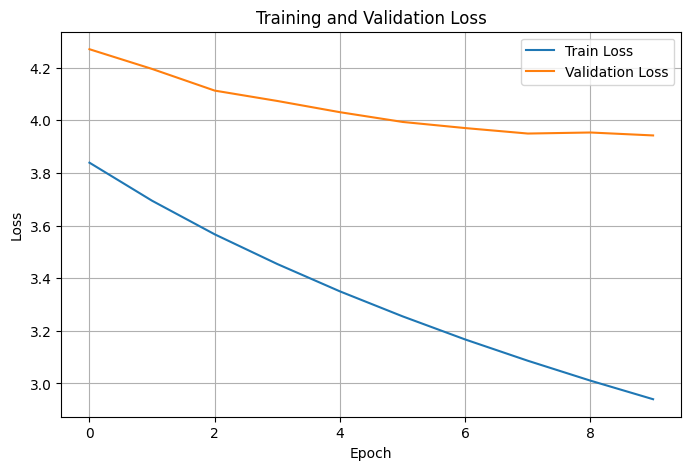

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#Translations

In [52]:
import torch.nn.functional as F

def beam_search_decode(
    model,
    src_sentence,
    tokenizer,
    device,
    max_len=100,
    beam_size=4,
    repetition_penalty=1.3
):
    model.eval()

    src_tokens = tokenizer(
        src_sentence,
        return_tensors="pt",
        truncation=True,
        max_length=max_len
    )

    src = src_tokens["input_ids"].to(device)

    bos_id = tokenizer.bos_token_id
    eos_id = tokenizer.eos_token_id

    beams = [([bos_id], 0.0)]
    completed_beams = []

    with torch.no_grad():
        for _ in range(max_len):
            new_beams = []

            for seq, score in beams:
                if seq[-1] == eos_id:
                    completed_beams.append((seq, score))
                    continue

                tgt_input = torch.tensor([seq], device=device)
                logits, _, _, _ = model(src, tgt_input)

                next_token_logits = logits[:, -1, :].squeeze(0).clone()

                for token_id in set(seq):
                    if next_token_logits[token_id] > 0:
                        next_token_logits[token_id] /= repetition_penalty
                    else:
                        next_token_logits[token_id] *= repetition_penalty

                log_probs = F.log_softmax(next_token_logits, dim=-1)

                top_log_probs, top_indices = torch.topk(log_probs, beam_size)

                for log_prob, token_id in zip(top_log_probs.tolist(), top_indices.tolist()):
                    new_seq = seq + [token_id]
                    new_score = score + log_prob
                    new_beams.append((new_seq, new_score))

            if not new_beams:
                break

            new_beams = sorted(new_beams, key=lambda x: x[1], reverse=True)
            beams = new_beams[:beam_size]

        completed_beams.extend(beams)

    completed_beams = sorted(
        completed_beams,
        key=lambda x: x[1] / (len(x[0]) ** 0.7),
        reverse=True
    )

    best_seq = completed_beams[0][0]

    if best_seq[0] == bos_id:
        best_seq = best_seq[1:]
    if eos_id in best_seq:
        best_seq = best_seq[:best_seq.index(eos_id)]

    return tokenizer.decode(best_seq, skip_special_tokens=True)



sample_indices = list(range(10))

for idx in sample_indices:
    src_text = test_ds[idx]["translation"]["de"]
    ref_text = test_ds[idx]["translation"]["en"]
    pred_text = beam_search_decode(
    model,
    src_text,
    tokenizer,
    device,
    max_len=100,
    beam_size=5,
    repetition_penalty=1.3
)

    print("=" * 80)
    print("German:    ", src_text)
    print("Reference: ", ref_text)
    print("Predicted: ", pred_text)


German:     Gutach: Noch mehr Sicherheit für Fußgänger
Reference:  Gutach: Increased safety for pedestrians
Predicted:  More safety :
German:     Sie stehen keine 100 Meter voneinander entfernt: Am Dienstag ist in Gutach die neue B 33-Fußgängerampel am Dorfparkplatz in Betrieb genommen worden - in Sichtweite der älteren Rathausampel.
Reference:  They are not even 100 metres apart: On Tuesday, the new B 33 pedestrian lights in Dorfparkplatz in Gutach became operational - within view of the existing Town Hall traffic lights.
Predicted:  On the left side , you will find no traffic l ights in B ach am pel : 100 me ters from R ath row Air port .
German:     Zwei Anlagen so nah beieinander: Absicht oder Schildbürgerstreich?
Reference:  Two sets of lights so close to one another: intentional or just a silly error?
Predicted:  Two main purpose : is it the intention to put an end in such a way ?
German:     Diese Frage hat Gutachs Bürgermeister gestern klar beantwortet.
Reference:  Yesterday, G